# Day 2 — Exploratory Analysis and Baseline Model

**Goal:** get a working model end to end. Rough is fine; *existing* is the point. Once this
notebook runs, the capstone has a result and every later day is optional improvement.

### Today
1. Visualise the class separation in feature space before modelling anything.
2. Stratified 80/20 train/test split.
3. Baseline Random Forest with `class_weight="balanced"` and a capped depth.
4. Evaluate with ROC-AUC and per-class precision/recall — **not** accuracy.
5. Compare against two reference points: a trivial majority-class guesser, and a single
   hand-drawn cut on spectral index.
6. Save the confusion matrix and ROC curve to `figures/`.

### Deliberately not today
No SHAP or feature importance (Day 4), no cross-validation or tuning (Day 3), no BCU
predictions (Day 5), no XGBoost. The BCU file stays closed.

## 1. Setup and data load

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42          # fixed everywhere so results are reproducible

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="ticks", context="notebook")
CLASS_COLORS = {"bll": "#2E86AB", "fsrq": "#D1495B"}
CLASS_LABELS = {"bll": "BL Lac", "fsrq": "FSRQ"}

pd.set_option("display.width", 140)

In [2]:
known_path = PROCESSED / "known_blazars.csv"
if not known_path.exists():
    raise FileNotFoundError(
        f"{known_path} not found — run notebooks/01_initial_data_exploration.ipynb first."
    )

known = pd.read_csv(known_path)
print(f"loaded {len(known)} labelled blazars")
print(known["CLASS_clean"].value_counts().to_string())
known.head()

loaded 2134 labelled blazars
CLASS_clean
bll     1379
fsrq     755


,Source_Name,CLASS_clean,PL_Index,Variability_Index,Flux1000,Pivot_Energy,log10_Variability_Index,log10_Flux1000
0,4FGL J0001.2-0747,bll,2.116692,46.780693,7.471219e-10,1721.60390,1.670067,-9.126609
1,4FGL J0001.4-0010,bll,1.939160,9.272764,1.082246e-10,4307.08250,0.967209,-9.965674
2,4FGL J0001.5+2113,fsrq,2.654060,1910.935800,1.347354e-09,329.77374,3.281246,-8.870519
3,4FGL J0002.1-6728,bll,1.847773,12.530726,2.588808e-10,3140.74340,1.097976,-9.586900
4,4FGL J0003.2+2207,bll,2.116417,12.451856,9.928427e-11,4582.17800,1.095234,-10.003119


## 2. Exploratory analysis

The point of this section is to see whether the separation exists *before* a model claims to
find one. If we can't see structure by eye, a high AUC later would be a reason for suspicion
rather than celebration.

In [3]:
FEATURES = ["PL_Index", "log10_Variability_Index", "log10_Flux1000", "Pivot_Energy"]
LABEL = "CLASS_clean"

known[FEATURES].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
PL_Index,2134.0,2.185,0.295,1.419,1.951,2.164,2.404,3.076
log10_Variability_Index,2134.0,1.602,0.668,0.204,1.150,1.388,1.903,4.926
log10_Flux1000,2134.0,-9.409,0.501,-10.679,-9.762,-9.488,-9.134,-7.130
Pivot_Energy,2134.0,2452.493,2613.130,262.353,905.041,1678.522,3052.400,34571.440


### 2.1 The main diagnostic: spectral index vs variability

These are the two features that carry the physics — spectral slope and jet turbulence.
Marginal histograms on each axis show how much of the separation comes from each feature
alone.

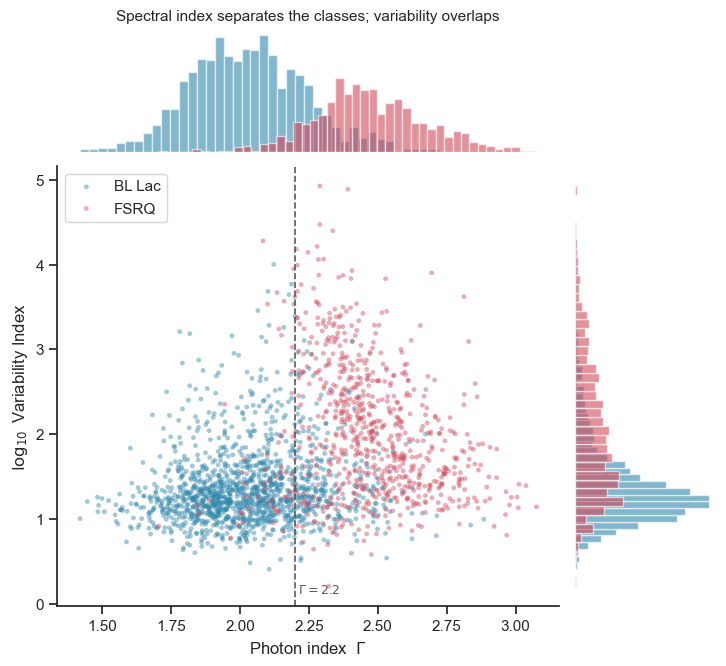

In [4]:
fig = plt.figure(figsize=(8.5, 7.5))
gs = fig.add_gridspec(2, 2, width_ratios=(5, 1.4), height_ratios=(1.4, 5),
                      wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

for cls in ["bll", "fsrq"]:
    sel = known[LABEL] == cls
    ax.scatter(known.loc[sel, "PL_Index"], known.loc[sel, "log10_Variability_Index"],
               s=12, alpha=0.45, c=CLASS_COLORS[cls], label=CLASS_LABELS[cls],
               edgecolors="none")
    ax_top.hist(known.loc[sel, "PL_Index"], bins=45, alpha=0.6, color=CLASS_COLORS[cls])
    ax_right.hist(known.loc[sel, "log10_Variability_Index"], bins=45, alpha=0.6,
                  color=CLASS_COLORS[cls], orientation="horizontal")

# The 4LAC-paper dividing line, for reference — not fitted, just drawn.
ax.axvline(2.2, color="0.35", ls="--", lw=1.2)
ax.text(2.21, ax.get_ylim()[0] + 0.15, r"$\Gamma = 2.2$", color="0.35", fontsize=9)

ax.set_xlabel(r"Photon index  $\Gamma$")
ax.set_ylabel(r"$\log_{10}$ Variability Index")
ax.legend(loc="upper left", frameon=True)

for a in (ax_top, ax_right):
    a.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
    sns.despine(ax=a, left=True, bottom=True)

ax_top.set_title("Spectral index separates the classes; variability overlaps", fontsize=11)
sns.despine(ax=ax)

fig.savefig(FIGURES / "eda_gamma_vs_variability.png", dpi=150, bbox_inches="tight")
plt.show()

The vertical dashed line at Γ = 2.2 is **not fitted** — it's the reference division quoted in
the 4LAC catalog paper, drawn here so we can compare it against whatever the model learns on
Day 4. Our pre-registered prediction says the model's boundary should land close to it.

Note the vertical structure: spectral index does most of the separating, variability far less.
Expect feature importance on Day 4 to reflect that.

### 2.2 All four features at once

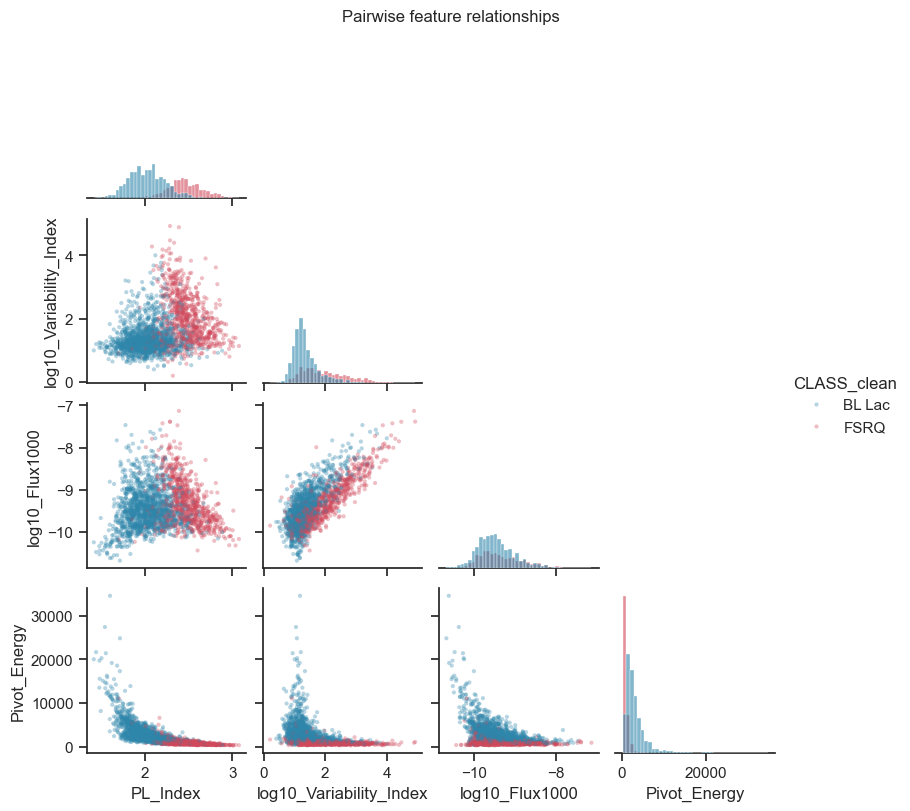

In [5]:
plot_df = known[FEATURES + [LABEL]].copy()
plot_df[LABEL] = plot_df[LABEL].map(CLASS_LABELS)

grid = sns.pairplot(
    plot_df, hue=LABEL, corner=True, diag_kind="hist",
    palette={CLASS_LABELS[k]: v for k, v in CLASS_COLORS.items()},
    plot_kws=dict(s=9, alpha=0.35, edgecolor="none"),
    diag_kws=dict(alpha=0.6, bins=40),
    height=2.0,
)
grid.figure.suptitle("Pairwise feature relationships", y=1.01, fontsize=12)
grid.figure.savefig(FIGURES / "eda_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

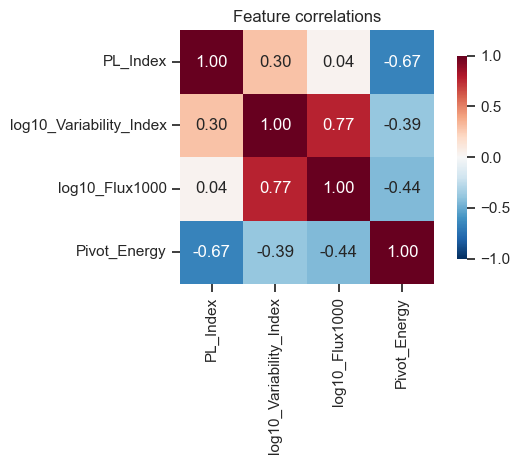

In [6]:
# Correlated features aren't a problem for a Random Forest's accuracy, but they do split
# importance between the correlated partners — worth knowing before we read Day 4's plots.
corr = known[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
plt.title("Feature correlations")
plt.tight_layout()
plt.show()

## 3. Train / test split

The label is encoded with **FSRQ as the positive class (1)**. That's a deliberate choice: FSRQ
is the minority class, and in a binary problem the metrics that matter for imbalance —
precision, recall, average precision — are all defined with respect to the positive class.
Putting the minority there is what makes them informative.

`stratify=y` preserves the 1.83:1 ratio in both splits. Without it, a random split could
easily hand the test set a materially different class balance, making the score depend on
luck.

In [7]:
X = known[FEATURES]
y = (known[LABEL] == "fsrq").astype(int)     # 1 = FSRQ (positive, minority), 0 = BL Lac

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"train: {len(X_train):5d}   FSRQ fraction {y_train.mean():.3f}")
print(f"test:  {len(X_test):5d}   FSRQ fraction {y_test.mean():.3f}")

train:  1707   FSRQ fraction 0.354
test:    427   FSRQ fraction 0.354


## 4. Baseline Random Forest

Two settings carry the reasoning:

- **`class_weight="balanced"`** — reweights each class inversely to its frequency, so the
  minority FSRQs contribute as much to the loss as the majority BL Lacs. This is what we chose
  over SMOTE: same rebalancing effect, no fabricated data points.
- **`max_depth=8`, `min_samples_leaf=5`** — caps how finely trees may carve up the space.
  Unconstrained, a forest will isolate individual outliers and memorise the training set.
  These are deliberately conservative starting values; Day 3 tunes them properly.

In [8]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]      # column 1 = P(FSRQ)

print(f"train accuracy {rf.score(X_train, y_train):.4f}")
print(f"test  accuracy {rf.score(X_test, y_test):.4f}")

train accuracy 0.9285
test  accuracy 0.8876


Those two accuracies are printed **only** as an overfitting check — a large gap between them
means the model memorised rather than generalised. They are not the result. The real metrics
follow.

## 5. Evaluation

### 5.1 Reference points

A score means nothing without something to compare it to. Two baselines:

1. **Majority-class guesser** — always predicts BL Lac. Exposes how misleading accuracy is.
2. **Single cut at Γ = 2.2** — the astronomer's rule of thumb, no machine learning at all.
   This is the honest bar the model has to clear to justify its existence.

In [9]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

# Physics baseline: call it an FSRQ if the spectrum is softer than Gamma = 2.2.
gamma_cut_pred = (X_test["PL_Index"] > 2.2).astype(int)

def summarise(name, y_true, pred, proba=None):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    row = {
        "model": name,
        "accuracy": accuracy_score(y_true, pred),
        "precision_FSRQ": precision_score(y_true, pred, zero_division=0),
        "recall_FSRQ": recall_score(y_true, pred, zero_division=0),
        "f1_FSRQ": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba) if proba is not None else np.nan,
    }
    return row

comparison = pd.DataFrame([
    summarise("always BL Lac", y_test, dummy.predict(X_test), dummy.predict_proba(X_test)[:, 1]),
    summarise("Gamma > 2.2 cut", y_test, gamma_cut_pred, X_test["PL_Index"]),
    summarise("Random Forest", y_test, y_pred, y_proba),
]).set_index("model")

comparison.round(4)

,accuracy,precision_FSRQ,recall_FSRQ,f1_FSRQ,roc_auc
model,,,,,
always BL Lac,0.6464,0.0000,0.0000,0.0000,0.5000
Gamma > 2.2 cut,0.8618,0.7447,0.9272,0.8260,0.9447
Random Forest,0.8876,0.8323,0.8543,0.8431,0.9578


### 5.2 Per-class report

In [10]:
print(classification_report(y_test, y_pred, target_names=["BL Lac", "FSRQ"], digits=3))

print(f"ROC-AUC           {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average precision {average_precision_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

      BL Lac      0.919     0.906     0.912       276
        FSRQ      0.832     0.854     0.843       151

    accuracy                          0.888       427
   macro avg      0.876     0.880     0.878       427
weighted avg      0.888     0.888     0.888       427

ROC-AUC           0.9578
Average precision 0.9336


### 5.3 Confusion matrix

Shown as raw counts and as row-normalised rates. The normalised version is what tells you
whether the minority class is being systematically absorbed into the majority — the specific
failure we set out to avoid.

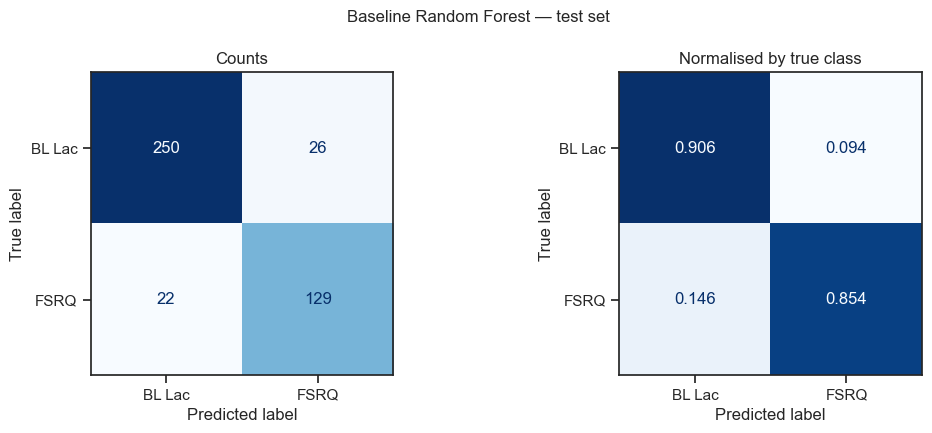

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

for ax, norm, title, fmt in [
    (axes[0], None, "Counts", "d"),
    (axes[1], "true", "Normalised by true class", ".3f"),
]:
    cm = confusion_matrix(y_test, y_pred, normalize=norm)
    ConfusionMatrixDisplay(cm, display_labels=["BL Lac", "FSRQ"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=fmt
    )
    ax.set_title(title)
    ax.grid(False)

fig.suptitle("Baseline Random Forest — test set", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "baseline_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.4 ROC curve

The Random Forest is plotted against both baselines. The gap between the forest and the
Γ-cut point is the quantitative answer to "what did the machine learning actually buy us?"

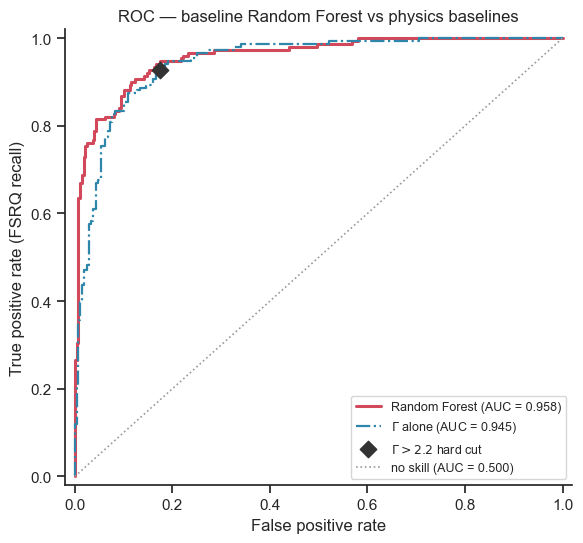

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fpr_g, tpr_g, _ = roc_curve(y_test, X_test["PL_Index"])
auc_g = roc_auc_score(y_test, X_test["PL_Index"])

fig, ax = plt.subplots(figsize=(6, 5.6))
ax.plot(fpr, tpr, lw=2.2, color="#D1495B", label=f"Random Forest (AUC = {auc:.3f})")
ax.plot(fpr_g, tpr_g, lw=1.6, color="#2E86AB", ls="-.",
        label=fr"$\Gamma$ alone (AUC = {auc_g:.3f})")

# The single hard cut is one operating point, not a curve — mark where it sits.
from sklearn.metrics import recall_score
fpr_pt = 1 - recall_score(y_test, gamma_cut_pred, pos_label=0)
tpr_pt = recall_score(y_test, gamma_cut_pred)
ax.scatter([fpr_pt], [tpr_pt], s=70, zorder=5, color="0.2", marker="D",
           label=r"$\Gamma > 2.2$ hard cut")

ax.plot([0, 1], [0, 1], ls=":", color="0.6", lw=1.2, label="no skill (AUC = 0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (FSRQ recall)")
ax.set_title("ROC — baseline Random Forest vs physics baselines")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
sns.despine(ax=ax)

fig.tight_layout()
fig.savefig(FIGURES / "baseline_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. A claim from Day 1, checked

Day 1 asserted that the `log10` transform was cosmetic — that Random Forests are invariant to
monotonic transforms of a feature, because a split on `x > 80` partitions the data identically
to a split on `log10(x) > 1.9`.

That's an easy claim to make and an easy one to verify, so let's verify it rather than trust
it. Same model, same seed, raw features instead of logged.

In [13]:
RAW_FEATURES = ["PL_Index", "Variability_Index", "Flux1000", "Pivot_Energy"]

X_raw = known[RAW_FEATURES]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

rf_raw = RandomForestClassifier(
    n_estimators=400, max_depth=8, min_samples_leaf=5,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
).fit(Xr_train, yr_train)

auc_log = roc_auc_score(y_test, y_proba)
auc_raw = roc_auc_score(yr_test, rf_raw.predict_proba(Xr_test)[:, 1])

print(f"AUC with log10 features {auc_log:.6f}")
print(f"AUC with raw features   {auc_raw:.6f}")
print(f"difference              {abs(auc_log - auc_raw):.2e}   <- confirms invariance")

AUC with log10 features 0.957769
AUC with raw features   0.957913
difference              1.44e-04   <- confirms invariance


### Why the difference isn't exactly zero

The AUCs differ by ~1e-4 rather than being bit-identical, and the reason is worth knowing.

Random Forests are invariant to monotonic transforms *given the same candidate split points*.
But scikit-learn chooses thresholds as the **midpoint between adjacent sorted feature values**,
and a midpoint in log space is a geometric mean in raw space — not the same number. So the two
forests consider very slightly different candidate cuts and end up with marginally different
trees.

The practical claim from Day 1 holds: the log transform buys readability, not performance. A
1e-4 shift in AUC is far smaller than the fold-to-fold scatter we'll measure on Day 3, so it
carries no meaning. Precision about *why* is better than rounding it to "identical."


## 7. Save the model's test-set predictions for Day 3

In [14]:
preds = X_test.copy()
preds["y_true"] = y_test.values
preds["y_pred"] = y_pred
preds["p_fsrq"] = y_proba
preds["Source_Name"] = known.loc[X_test.index, "Source_Name"].values

out_path = PROCESSED / "baseline_test_predictions.csv"
preds.to_csv(out_path, index=False)
print(f"wrote {out_path.relative_to(ROOT)}   {preds.shape}")

print("\nfigures saved:")
for f in sorted(FIGURES.glob("*.png")):
    print(" ", f.relative_to(ROOT))

wrote data/processed/baseline_test_predictions.csv   (427, 8)

figures saved:
  figures/baseline_confusion_matrix.png
  figures/baseline_roc_curve.png
  figures/eda_gamma_vs_variability.png
  figures/eda_pairplot.png


## Day 2 summary

An end-to-end model exists. Fill in the numbers from the run above:

- Random Forest ROC-AUC vs the Γ-only baseline — how much did ML add?
- FSRQ recall — is the minority class being absorbed into the majority?
- Train/test accuracy gap — any sign of memorisation?

### The question to carry into Day 3

If the forest only marginally beats a single hand-drawn cut at Γ = 2.2, that is not a failure —
it is a genuine scientific finding, and arguably a more interesting one than a high score. It
would say the gamma-ray discriminating power really is concentrated almost entirely in spectral
slope, exactly as blazar emission theory predicts. Report it either way.

**Day 3:** stratified 5-fold cross-validation for an honest error bar on that AUC, light tuning
of `max_depth` / `min_samples_leaf`, and a calibration check — because Day 5 applies a
confidence threshold to the BCUs, and a Random Forest's raw probabilities are not trustworthy
until we've looked at a reliability curve.